# 📊 E-Commerce Sales Analysis

An end-to-end exploratory data analysis (EDA) of an e-commerce sales dataset using **Python (Pandas, SQLite, Matplotlib, Seaborn)** and **statistical/ML modeling (SciPy, Scikit-learn)**.

## Contents
1. Data Cleaning & Preparation
2. KPI Summary
3. Product Category Analysis
4. Region Analysis
5. Customer Segment Analysis
6. Country-wise Analysis
7. Monthly & Yearly Trends
8. Top / Least Buying Customers & Payment Method Analysis
9. Correlation Analysis
10. Statistical Tests (T-Test, ANOVA, Pearson Correlation)
11. Predictive Modeling (Linear Regression)
12. **Overall Summary & Recommendations**

---


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql

In [33]:
# Path to dataset (place ecommerceSales.csv in the same folder as this notebook,
# or update the path below to match your local/Colab location)
path = "ecommerceSales.csv"


In [34]:
SalesAnalysis = pd.read_csv(path)

In [35]:
#.Null Checking:
Null_Checking = SalesAnalysis.isnull().sum()


print(Null_Checking)


Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64


In [36]:
#.Checking Duplicates:
Duplicates_Checking = SalesAnalysis.duplicated().sum()
print(Duplicates_Checking)

0


In [37]:
print("Shape:", SalesAnalysis.shape)
print("\nData Types:\n", SalesAnalysis.dtypes)
print("\nBasic Stats:\n")
SalesAnalysis.describe().round(2)

Shape: (2000, 15)

Data Types:
 Order_ID             object
Order_Date           object
Customer_Name        object
Customer_Segment     object
Country              object
Region               object
Product_Category     object
Product_Name         object
Quantity              int64
Unit_Price          float64
Discount_Percent      int64
Total_Sales         float64
Shipping_Cost       float64
Profit              float64
Payment_Method       object
dtype: object

Basic Stats:



,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,3.56,73.33,8.57,242.28,12.90,79.44
std,2.70,79.31,7.26,382.58,5.22,137.57
min,1.00,3.03,0.00,2.42,5.52,-11.28
25%,2.00,18.76,0.00,41.23,9.46,6.86
50%,3.00,46.42,10.00,113.12,11.84,32.83
75%,5.00,90.25,15.00,266.55,14.92,90.30
max,15.00,472.56,30.00,3813.98,40.44,1373.63


In [38]:
SalesAnalysis['Order_Date'] = pd.to_datetime(SalesAnalysis['Order_Date'],format='%d-%m-%Y')

# KPI


In [39]:
print("=" * 45)
print("         SALES ANALYSIS - KPI SUMMARY")
print("=" * 45)
print(f"Total Revenue     : ${SalesAnalysis['Total_Sales'].sum():,.2f}")
print(f"Total Profit      : ${SalesAnalysis['Profit'].sum():,.2f}")
print(f"Total Orders      : {SalesAnalysis['Order_ID'].nunique()}")
print(f"Avg Order Value   : ${SalesAnalysis['Total_Sales'].mean():,.2f}")
print(f"Profit Margin     : {SalesAnalysis['Profit'].sum()/SalesAnalysis['Total_Sales'].sum()*100:.2f}%")
print(f"Top Region        : {SalesAnalysis.groupby('Region')['Total_Sales'].sum().idxmax()}")
print("=" * 45)

         SALES ANALYSIS - KPI SUMMARY
Total Revenue     : $484,559.34
Total Profit      : $158,872.32
Total Orders      : 2000
Avg Order Value   : $242.28
Profit Margin     : 32.79%
Top Region        : Europe


In [40]:
#.Upload In Sql:

In [41]:
conn = sql.connect("SalesAnalysis.db")
SalesAnalysis.to_sql("SalesAnalysis",conn,if_exists="replace",index=False)
print("Data Loaded Sucessfully")

Data Loaded Sucessfully


In [42]:
pd.read_sql("select * from SalesAnalysis limit 5",conn)


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02 00:00:00,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02 00:00:00,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03 00:00:00,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03 00:00:00,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05 00:00:00,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [43]:
#.Total_Sales

In [124]:
Sales = pd.read_sql("""
 Select Product_Category,
 Count(Quantity) As Total_Orders,
 Sum(Total_Sales) As Total_Sales,
 Sum(Profit) As Total_Profits,
 round(Sum(Profit)/Sum(Total_Sales)*100,2) AS Profit_Margins

 From SalesAnalysis
 group by Product_Category
 order by Total_Sales desc
""",conn)
Sales

,Product_Category,Total_Orders,Total_Sales,Total_Profits,Profit_Margins
0,Furniture,507,256274.68,81171.57,31.67
1,Technology,567,139518.22,48268.65,34.60
2,Clothing & Accessories,413,69375.63,26112.94,37.64
3,Office Supplies,513,19390.81,3319.16,17.12


# Product Category Analysis

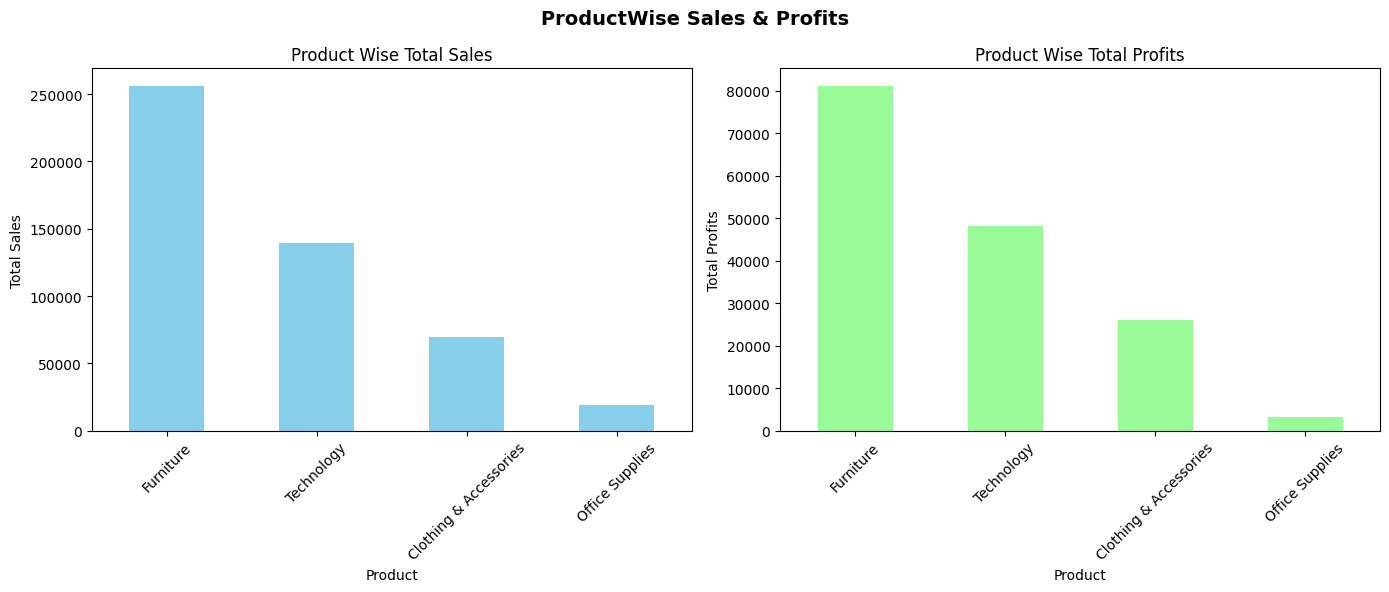

In [49]:
Productwise = pd.read_sql("""
select Product_Category,
sum(Total_Sales) As Sales,
sum(Profit) as Total_Profit
From SalesAnalysis
Group by Product_Category
Order by Sales DESC

""",conn)
#Charts1:
fig,ax=plt.subplots(1,2,figsize=(14,6))
plt.suptitle("ProductWise Sales & Profits",fontsize=14,fontweight="bold" )
Productwise.plot(kind='bar',x='Product_Category',y='Sales',color='skyblue',ax=ax[0],legend=False)
ax[0].set_title("Product Wise Total Sales")
ax[0].set_xlabel("Product")
ax[0].set_ylabel("Total Sales")
ax[0].tick_params(axis='x',rotation=45)
Productwise.plot(kind='bar',x='Product_Category',y='Total_Profit',color='palegreen',ax=ax[1],legend=False)
ax[1].set_title("Product Wise Total Profits")
ax[1].set_xlabel("Product")
ax[1].set_ylabel("Total Profits")
ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()


          Product_Category  Year  Total_Sale  Growth_%
0   Clothing & Accessories  2023    20023.55       NaN
1                Furniture  2023    92646.53       NaN
2          Office Supplies  2023     6048.43       NaN
3               Technology  2023    45724.94       NaN
4   Clothing & Accessories  2024    25383.08     26.77
5                Furniture  2024    77555.58    -16.29
6          Office Supplies  2024     6810.80     12.60
7               Technology  2024    45401.27     -0.71
8   Clothing & Accessories  2025    23969.00     -5.57
9                Furniture  2025    86072.57     10.98
10         Office Supplies  2025     6531.58     -4.10
11              Technology  2025    48392.01      6.59


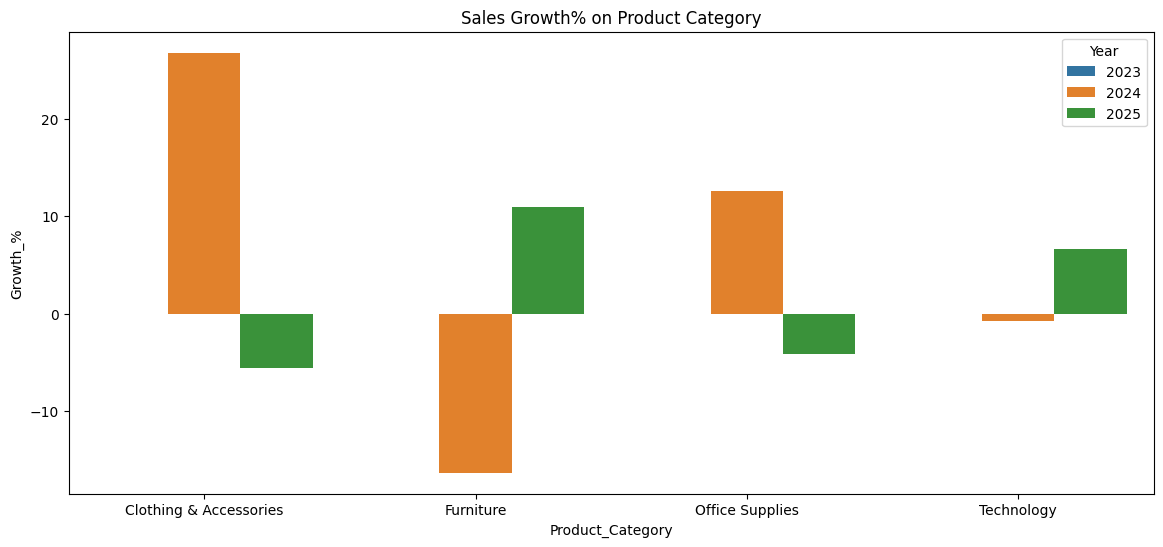

In [50]:
Category_Sale = pd.read_sql("""
   select
    Product_Category,
    strftime('%Y', Order_Date) As Year,
    Sum(Total_Sales) As Total_Sale
    from SalesAnalysis
    group by Year,Product_Category
    Order By Year

""", conn)
Category_Sale['Growth_%'] =(Category_Sale.groupby('Product_Category')['Total_Sale'].pct_change() * 100
                         ).round(2)
print(Category_Sale)
fig,ax=plt.subplots(1,1,figsize=(14,6))
sns.barplot(data=Category_Sale,x='Product_Category',y='Growth_%',hue='Year')
plt.title("Sales Growth% on Product Category")
plt.show()


         Product_Category  Profit_Margin_Pct
0  Clothing & Accessories              37.64
1              Technology              34.60
2               Furniture              31.67
3         Office Supplies              17.12


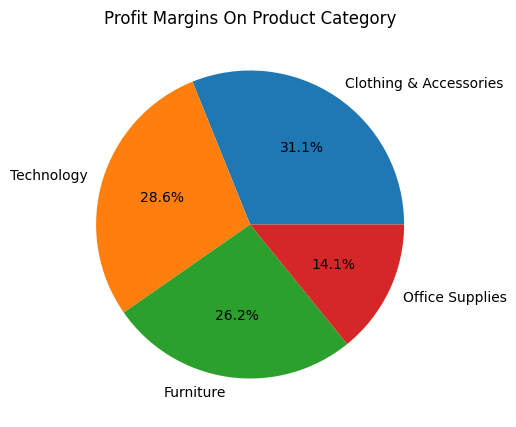

In [125]:
Profit_Margin = pd.read_sql("""
    SELECT Product_Category,
    ROUND(SUM(Profit) / SUM(Total_Sales) * 100, 2) AS Profit_Margin_Pct
    FROM SalesAnalysis
    GROUP BY Product_Category
    ORDER BY Profit_Margin_Pct DESC
""", conn)
print(Profit_Margin)
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(Profit_Margin['Profit_Margin_Pct'],labels=Profit_Margin['Product_Category'],
                  autopct='%1.1f%%')
plt.title("Profit Margins On Product Category")
plt.show()

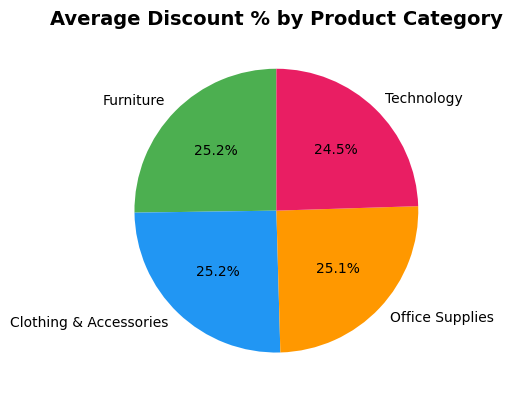

In [131]:
Product_Discount = pd.read_sql("""
select Product_Category,
round( Avg(Discount_Percent),2) as Avg_Discountpct
 from SalesAnalysis
 Group by Product_Category
 order by Avg_Discountpct desc
""",conn)
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    Product_Discount['Avg_Discountpct'],
    labels=Product_Discount['Product_Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#2196F3', '#FF9800', '#E91E63']
)

ax.set_title('Average Discount % by Product Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 Insights On Product Category:
         **Furniture** Is high Sales Generationg Product And also High Profit Generating Product. its Salevalue = 2,56,274.68 and profits = 81,171.57  though it is High Sales And Profit Generating Product But Its Profit Margins is 3rd highest profit margins is 31.67 % .its Sales Ration Compared to Previous year Is Incerasing 10.98% discount percentage provaided for the furniture is 25.2 % **high discount reduces **the profit margins
         **Office Supplies** Which is low sales and profit generating product its Sale value is 19390.81 and its profit value is 3319.16 and also its profit margins is 17.12% .Sales Ration Comparder To Provious Year is  decreasing -4.10% .discount percentage provaided 25.1% is 2nd highest discount percentage
NOTE:
    Instead of investing on Office Supplies Which Sales and Profit And Its Profit Margins Also less invest On either Cloathing Or Technology
    Cloathing Sales Value 69,375.63	 and profit Value = 26,112.94 its Profit Margins Is 31.1 is highest of all  but its Sales Ration Comapred to previous year it is on decreasing -5.57%
    Technology Sales Value 1,39,518.22	 and profit Value = 48,268.65 its Profit Margins Is 28.6% is 2ndhighest of all  but its Sales Ration Comapred to previous year it is on Increasing 6.59%	.
    Investing on Technology may Increasing profit margins because its Sales is increased from previous year.

# Region Analysis

                 Region      Sales  Total_Profits
0                Europe  137006.20       45672.16
1         North America  133876.38       45250.09
2          Asia Pacific  121707.51       39116.61
3         South America   46051.13       14680.98
4  Middle East & Africa   45918.12       14152.48


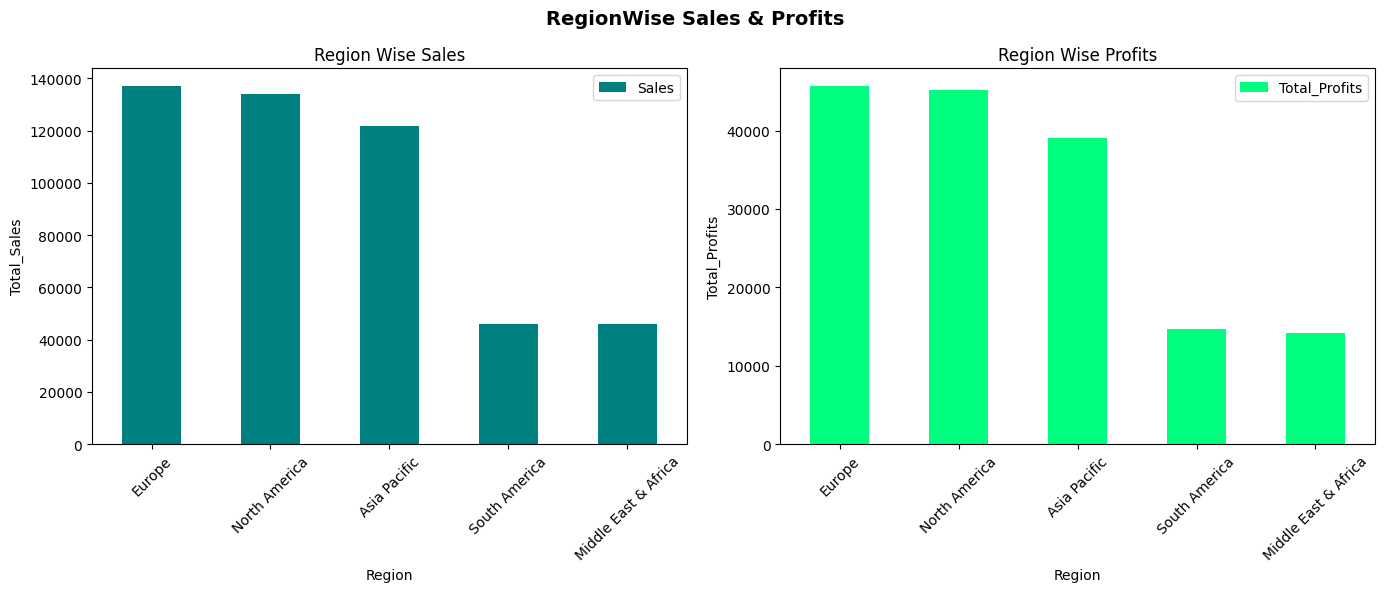

In [133]:
Regionwise =pd.read_sql("""
select Region,
sum(Total_Sales) As Sales,
sum(Profit) As Total_Profits
from SalesAnalysis
Group by Region
Order by Sales Desc
""",conn)
print(Regionwise)
#Charts1:
fig,ax=plt.subplots(1,2,figsize=(14,6))
plt.suptitle("RegionWise Sales & Profits",fontsize=14,fontweight="bold" )
Regionwise.plot(kind='bar',x='Region',y='Sales',ax=ax[0],color='teal')
ax[0].set_title('Region Wise Sales')
ax[0].set_xlabel('Region')
ax[0].set_ylabel('Total_Sales')
ax[0].tick_params(axis='x',rotation=45)
#chart2
Regionwise.plot(kind='bar',x='Region',y='Total_Profits',ax=ax[1],color='springgreen')
ax[1].set_title('Region Wise Profits')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('Total_Profits')
ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()


                  Region  Year  Total_Sale  Growth_%
0           Asia Pacific  2023    44933.73       NaN
1                 Europe  2023    39397.21       NaN
2   Middle East & Africa  2023    18573.46       NaN
3          North America  2023    42248.10       NaN
4          South America  2023    19290.95       NaN
5           Asia Pacific  2024    36776.69    -18.15
6                 Europe  2024    41556.70      5.48
7   Middle East & Africa  2024    13339.23    -28.18
8          North America  2024    47893.21     13.36
9          South America  2024    15584.90    -19.21
10          Asia Pacific  2025    39997.09      8.76
11                Europe  2025    56052.29     34.88
12  Middle East & Africa  2025    14005.43      4.99
13         North America  2025    43735.07     -8.68
14         South America  2025    11175.28    -28.29


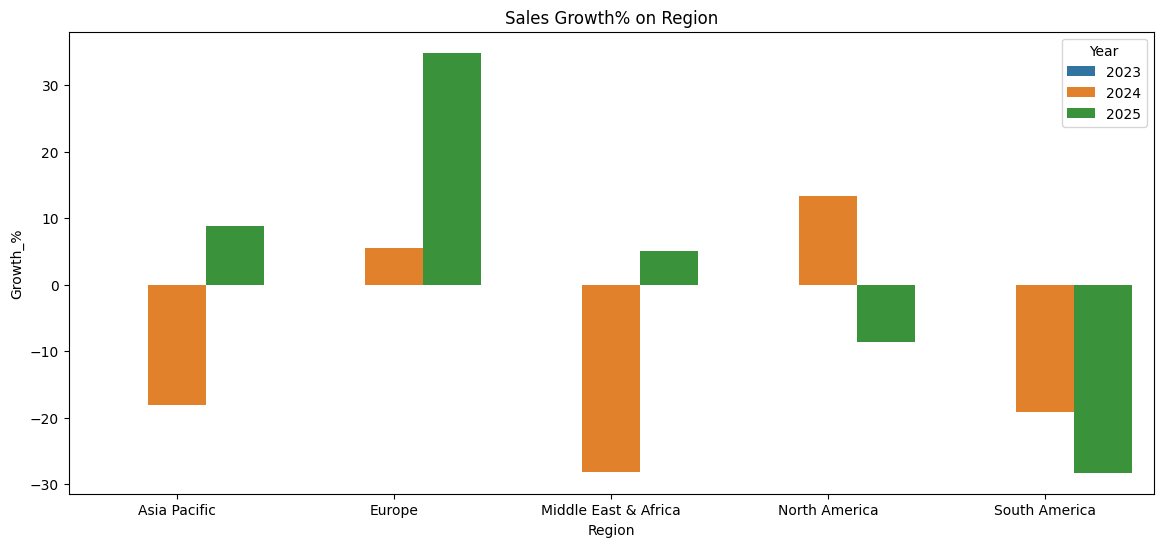

In [132]:
Region_Sale = pd.read_sql("""
    select
    Region,
    strftime('%Y', Order_Date) As Year,
    Sum(Total_Sales) As Total_Sale
    from SalesAnalysis
    group by Year,Region
    Order By Year
""", conn)
Region_Sale['Growth_%'] =(Region_Sale.groupby('Region')['Total_Sale'].pct_change() * 100
                         ).round(2)
print(Region_Sale)
fig,ax=plt.subplots(1,1,figsize=(14,6))
sns.barplot(data=Region_Sale,x='Region',y='Growth_%',hue='Year')
plt.title("Sales Growth% on Region")
plt.show()

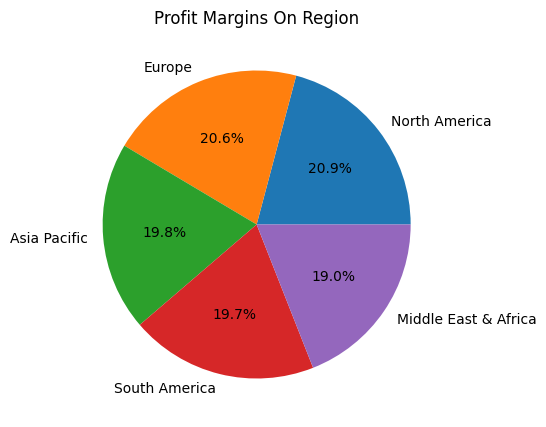

In [54]:
Profit_Margin = pd.read_sql("""
    SELECT Region,
    ROUND(SUM(Profit) / SUM(Total_Sales) * 100, 2) AS Profit_Margin_Pct
    FROM SalesAnalysis
    GROUP BY Region
    ORDER BY Profit_Margin_Pct DESC
""", conn)
Profit_Margin
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(Profit_Margin['Profit_Margin_Pct'],labels=Profit_Margin['Region'],
                  autopct='%1.1f%%')
plt.title("Profit Margins On Region")
plt.show()

                 Region  Avg_Discountpct
0         South America             9.29
1          Asia Pacific             8.89
2         North America             8.37
3                Europe             8.37
4  Middle East & Africa             8.17


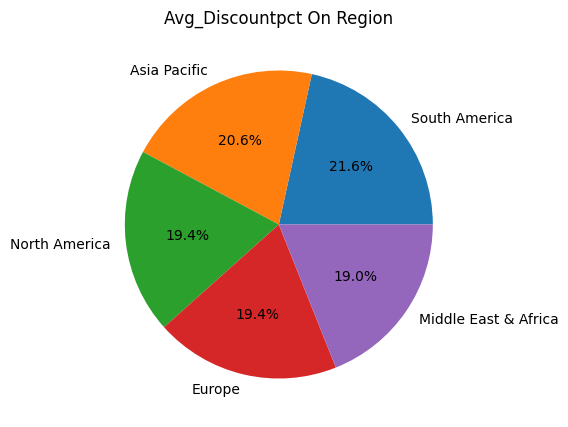

In [134]:
Region_Discount= pd.read_sql("""
    SELECT Region,
    ROUND(Avg(Discount_Percent), 2) AS Avg_Discountpct
    FROM SalesAnalysis
    GROUP BY Region
    ORDER BY Avg_Discountpct DESC
""", conn)
print(Region_Discount)
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(Region_Discount['Avg_Discountpct'],labels=Region_Discount['Region'],
                  autopct='%1.1f%%')
plt.title("Avg_Discountpct On Region")
plt.show()

Insights On Region:
     Europe region is High Sales Region Sales Value=1,37,006.20.profit value =  45,672.16 its profit margin is 20.6 % and its sales growth comparded to proveious year is increasing 34.88 % its Discount percentage is 19.4%.
     North America is 2nd high on Sale its Sales value=1,33,876.38.profit value =45,250.09 its profit margins is 20.9% is highest on region its Sales Growth Compared to Previous Year is declined 2025 Sales growth=-8.68%
     its Discount percentage is 19.4%.
     Middle East & Africa is lowest Sales and Profit Generating At Region its Sales Value =45,918.12.its Profit Value is =14,152.48 its Profit Margins is 19% and its Sales growth Is  4.99 % and its Discount is 19 %
     South America 2nd Lowest At Sales And profit Sale Value is =46,051.13 .its Proifits Value is = 14,680.98 its Profit margin is 19.7% is good but its Sale Growth Is Declained Comparded to pervious year-28.29 % its Discount is 21.6 %

NOTE:
there is not much Different is High Sales Region On Its Sales And Profits only Different is Its Sales Growth From Previous Year Europe is On Higher on Sales and Profits
Lowest Sales And Profit Generating Region Middle East& africa ,South America.
South America Is at least by Its Sales Growth And Its Discount percentage


# Customer_Segment Analysis

  Customer_Segment      Sales  Total_Profits
0         Consumer  256287.74       87300.36
1        Corporate  146050.39       44463.44
2      Home Office   82221.21       27108.52


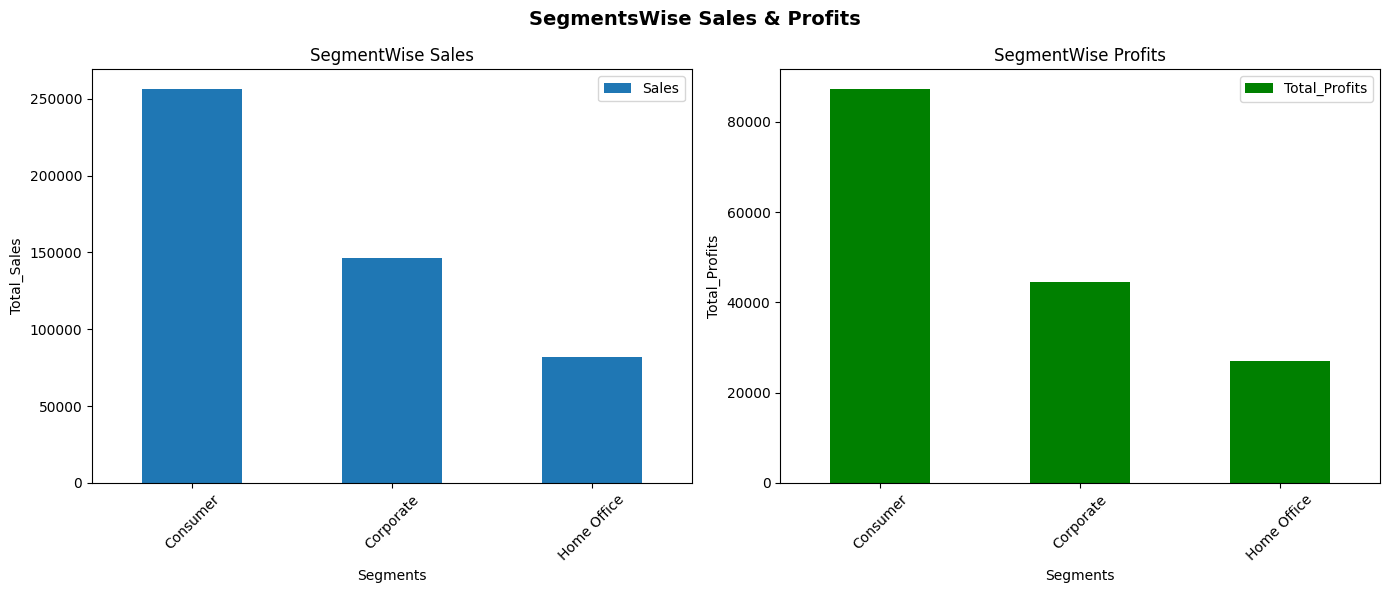

In [137]:
Segment =pd.read_sql("""
select Customer_Segment,
sum(Total_Sales) As Sales,
sum(Profit) As Total_Profits
From SalesAnalysis
Group by Customer_Segment
order by Sales desc
""",conn)
print(Segment)
#Charts:
fig,ax=plt.subplots(1,2,figsize=(14,6))
plt.suptitle("SegmentsWise Sales & Profits",fontsize=14,fontweight="bold" )
Segment.plot(kind='bar',x='Customer_Segment',y='Sales',ax=ax[0])
ax[0].set_title('SegmentWise Sales')
ax[0].set_xlabel('Segments')
ax[0].set_ylabel('Total_Sales')
ax[0].tick_params(axis='x',rotation=45)
#Charts1:

Segment.plot(kind='bar',x='Customer_Segment',y='Total_Profits',ax=ax[1],color='green')
ax[1].set_title('SegmentWise Profits')
ax[1].set_xlabel('Segments')
ax[1].set_ylabel('Total_Profits')
ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

  Customer_Segment  Year  Total_Sale  Growth_%
0         Consumer  2023    86912.07       NaN
1        Corporate  2023    46264.95       NaN
2      Home Office  2023    31266.43       NaN
3         Consumer  2024    89029.31      2.44
4        Corporate  2024    46430.75      0.36
5      Home Office  2024    19690.67    -37.02
6         Consumer  2025    80346.36     -9.75
7        Corporate  2025    53354.69     14.91
8      Home Office  2025    31264.11     58.78


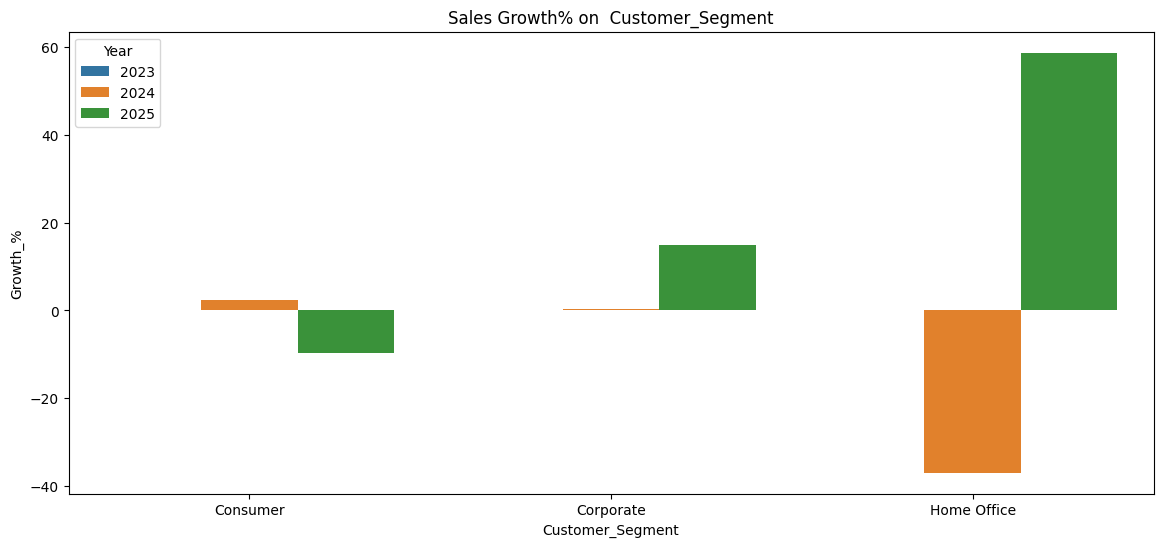

In [138]:
#.Sales Growth%:
Segment_Sale = pd.read_sql("""
    select
     Customer_Segment,
    strftime('%Y', Order_Date) As Year,
    Sum(Total_Sales) As Total_Sale
    from SalesAnalysis
    group by Year, Customer_Segment
    Order By Year
""", conn)
Segment_Sale['Growth_%'] =(Segment_Sale.groupby('Customer_Segment')['Total_Sale'].pct_change() * 100
                         ).round(2)
print(Segment_Sale)
fig,ax=plt.subplots(1,1,figsize=(14,6))
sns.barplot(data=Segment_Sale,x='Customer_Segment',y='Growth_%',hue='Year')
plt.title("Sales Growth% on  Customer_Segment")
plt.show()

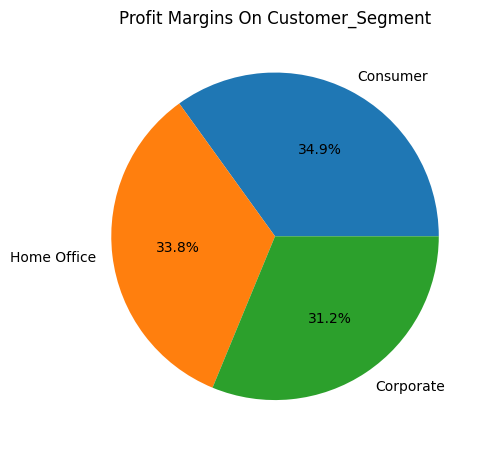

In [130]:
Profit_Margin = pd.read_sql("""
    SELECT Customer_Segment,
    ROUND(SUM(Profit) / SUM(Total_Sales) * 100, 2) AS Profit_Margin_Pct
    FROM SalesAnalysis
    GROUP BY Customer_Segment
    ORDER BY Profit_Margin_Pct DESC
""", conn)
Profit_Margin
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(Profit_Margin['Profit_Margin_Pct'],labels=Profit_Margin['Customer_Segment'],
                  autopct='%1.1f%%')
plt.title("Profit Margins On Customer_Segment")




plt.tight_layout()
plt.show()

  Customer_Segment  Avg_Discountpct
0        Corporate            11.25
1      Home Office             7.80
2         Consumer             7.20


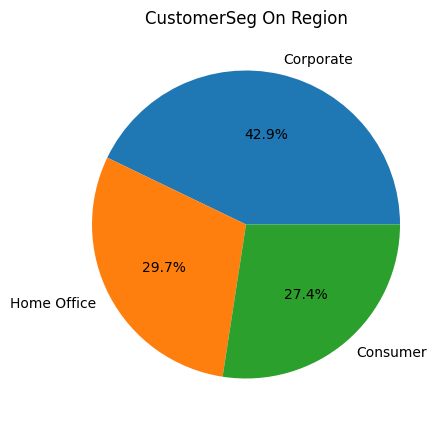

In [136]:
CustomerSeg= pd.read_sql("""
    SELECT Customer_Segment,
    ROUND(Avg(Discount_Percent), 2) AS Avg_Discountpct
    FROM SalesAnalysis
    GROUP BY Customer_Segment
    ORDER BY Avg_Discountpct DESC
""", conn)
print(CustomerSeg)
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(CustomerSeg['Avg_Discountpct'],labels=CustomerSeg['Customer_Segment'],
                  autopct='%1.1f%%')
plt.title("CustomerSeg On Region")
plt.show()

Insights On Customer Segments:
 Consumer Segments Is Highest on Sales and Profit  Its Sale Value =256287.74    ,Profit Value = 87300.36      But its Sales Growth Is Declained in Compared to Previouus Year -9.75  , Its Profit Margins is34.9%And Its Discount is 7.20 %        
  Home Office is Least Sale and Profit Generating in Segments Sales Value=   82221.21,profit Value is 27108.52 its Profit Margin is 33.8% and its Discount =7.80. its Sales Growth is high 58.78 %
  NOTE:
  Why Consumer Segments in High Sales And profit Because its Discount % is less .

# Country

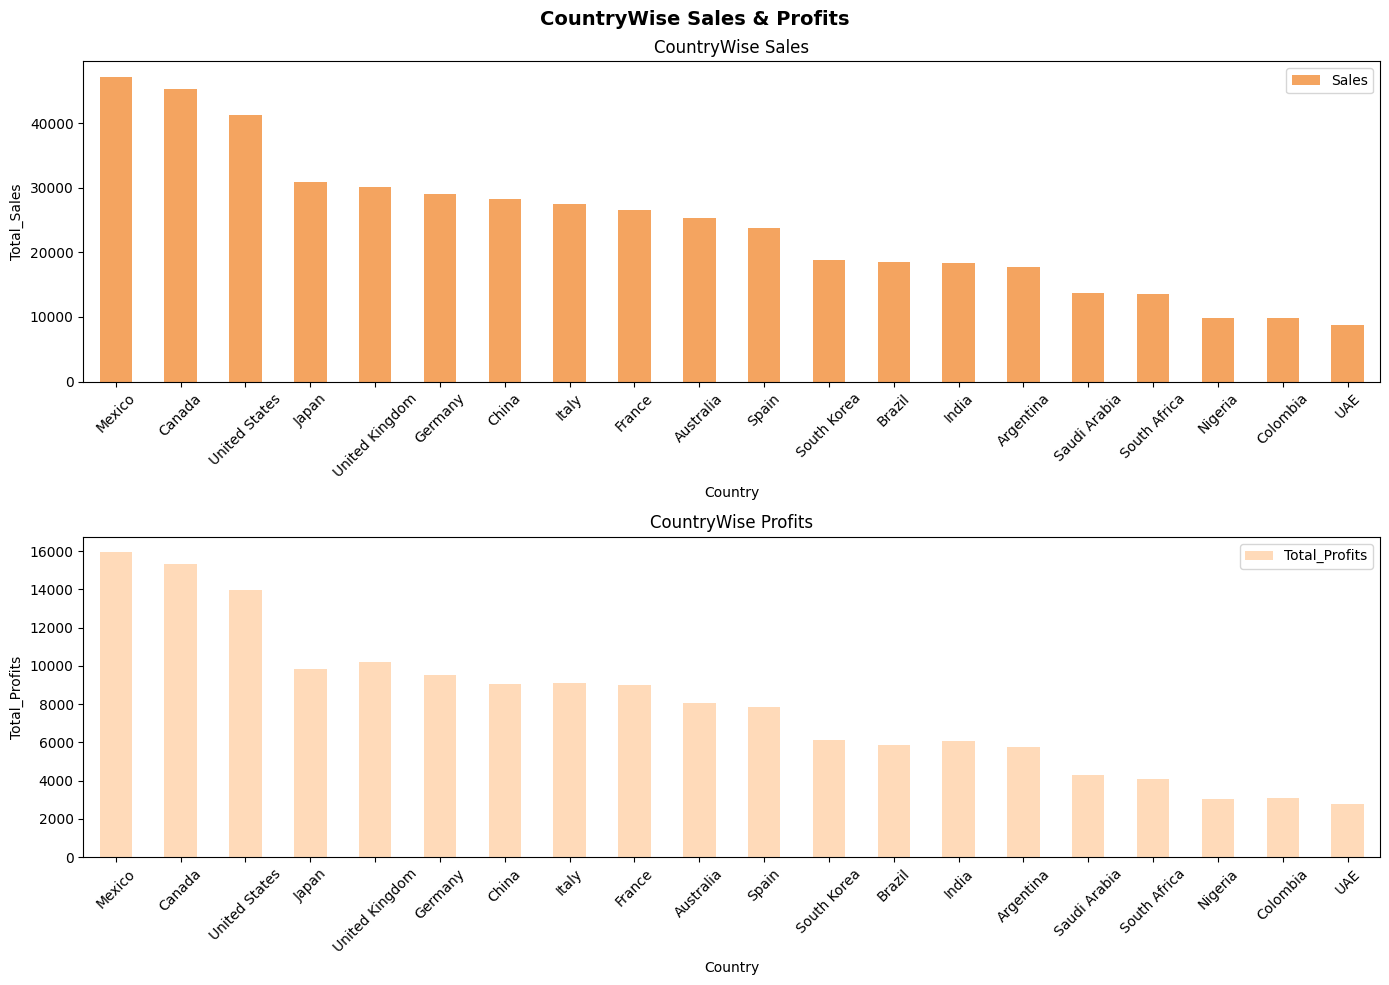

In [139]:
Countrywise =pd.read_sql("""
Select Country,
sum(Total_Sales) As Sales,
sum(Profit) As Total_Profits
From SalesAnalysis
Group by Country
order by Sales desc
""",conn)
#Charts 1:
fig,ax=plt.subplots(2,1,figsize=(14,10))
plt.suptitle("CountryWise Sales & Profits",fontsize=14,fontweight="bold" )
Countrywise.plot(kind='bar',x='Country',y='Sales',ax=ax[0],color='sandybrown')
ax[0].set_title('CountryWise Sales')
ax[0].set_xlabel('Country')
ax[0].set_ylabel('Total_Sales')
ax[0].tick_params(axis='x',rotation=45)
#Charts1:

Countrywise.plot(kind='bar',x='Country',y='Total_Profits',ax=ax[1],color='peachpuff')
ax[1].set_title('CountryWise Profits')
ax[1].set_xlabel('Country')
ax[1].set_ylabel('Total_Profits')
ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()


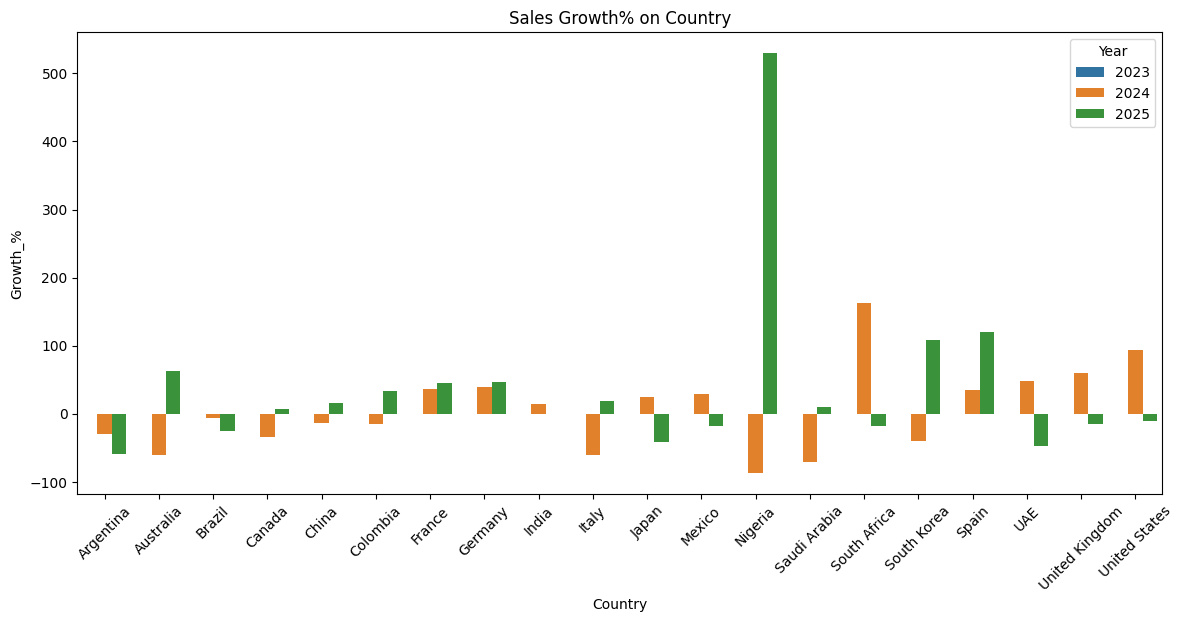

In [140]:
Country_Salepct = pd.read_sql("""
    select
    Country,
    strftime('%Y', Order_Date) As Year,
    Sum(Total_Sales) As Total_Sale
    from SalesAnalysis
    group by Year,Country
    Order By Year
""", conn)
Country_Salepct['Growth_%'] =(Country_Salepct.groupby('Country')['Total_Sale'].pct_change() * 100
                         ).round(2)
Country_Salepct
fig,ax=plt.subplots(1,1,figsize=(14,6))
sns.barplot(data=Country_Salepct,x='Country',y='Growth_%',hue='Year')
plt.title("Sales Growth% on Country")
plt.xticks(rotation=45)
plt.show()

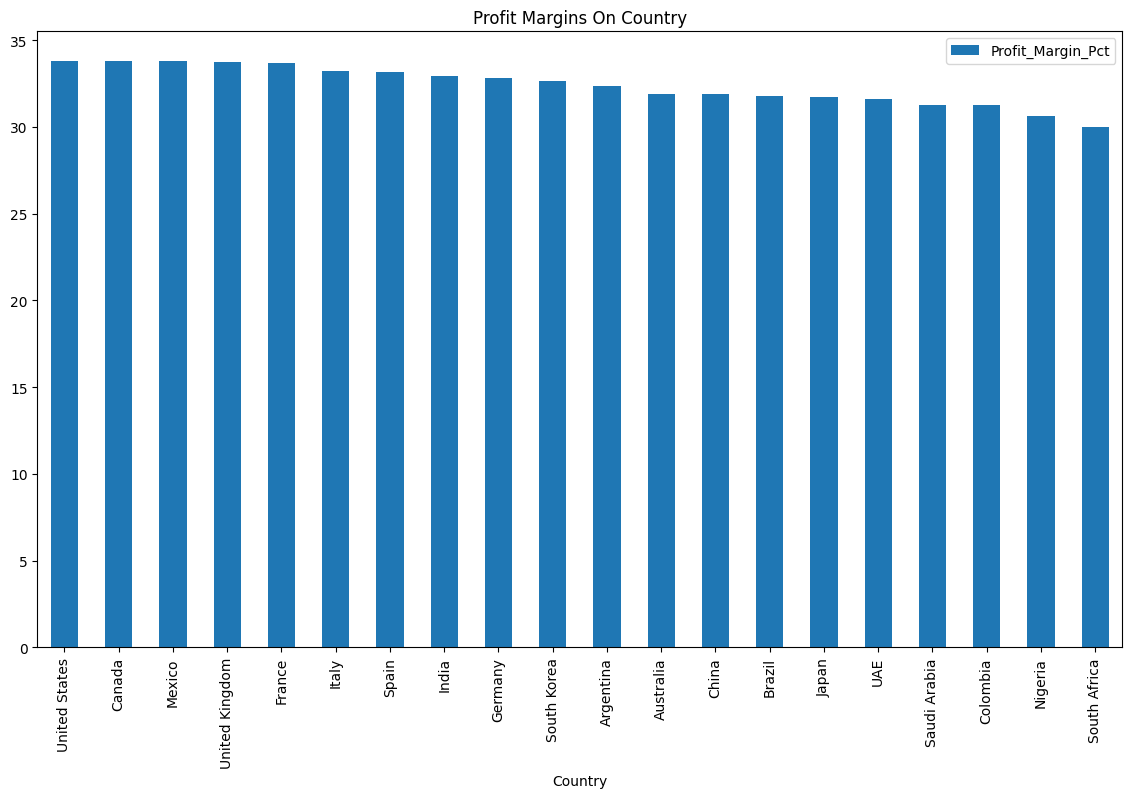

In [141]:
Country_ProfitMargins = pd.read_sql("""
    SELECT Country,
    ROUND(SUM(Profit) / SUM(Total_Sales) * 100, 2) AS Profit_Margin_Pct
    FROM SalesAnalysis
    GROUP BY Country
    ORDER BY Profit_Margin_Pct DESC
""", conn)
Country_ProfitMargins

Country_ProfitMargins.plot(kind='bar',x='Country',y='Profit_Margin_Pct',figsize=(14,8))
plt.title("Profit Margins On Country")
plt.show()

In [61]:
#.Montly Sales And ProfitTrend:

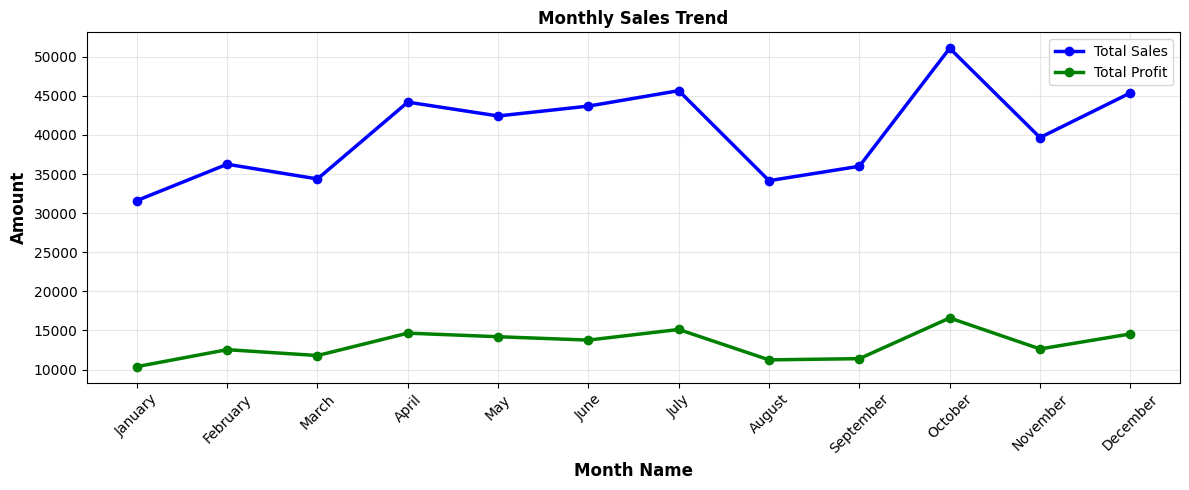

In [62]:
Monthly_Analysis =pd.read_sql("""
select strftime('%m',Order_Date) As Month,
Sum(Total_Sales) As Total_Sale,
sum(Profit) As Profits
From SalesAnalysis
Group by Month
Order By Month
""",conn)
Monthly_Analysis['Month_Name']  =pd.to_datetime(Monthly_Analysis['Month'],format='%m').dt.strftime('%B')
plt.figure(figsize=(12,5))

plt.plot(Monthly_Analysis['Month_Name'],Monthly_Analysis['Total_Sale'],marker='o',linewidth=2.5,color='blue',label='Total Sales')
plt.plot(Monthly_Analysis['Month_Name'],Monthly_Analysis['Profits'],marker='o',linewidth=2.5,color='green',label='Total Profit')
plt.title('Monthly Sales Trend',fontsize=12,fontweight='bold')
plt.xlabel('Month Name',fontsize=12,fontweight='bold')
plt.ylabel('Amount',fontsize=12,fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

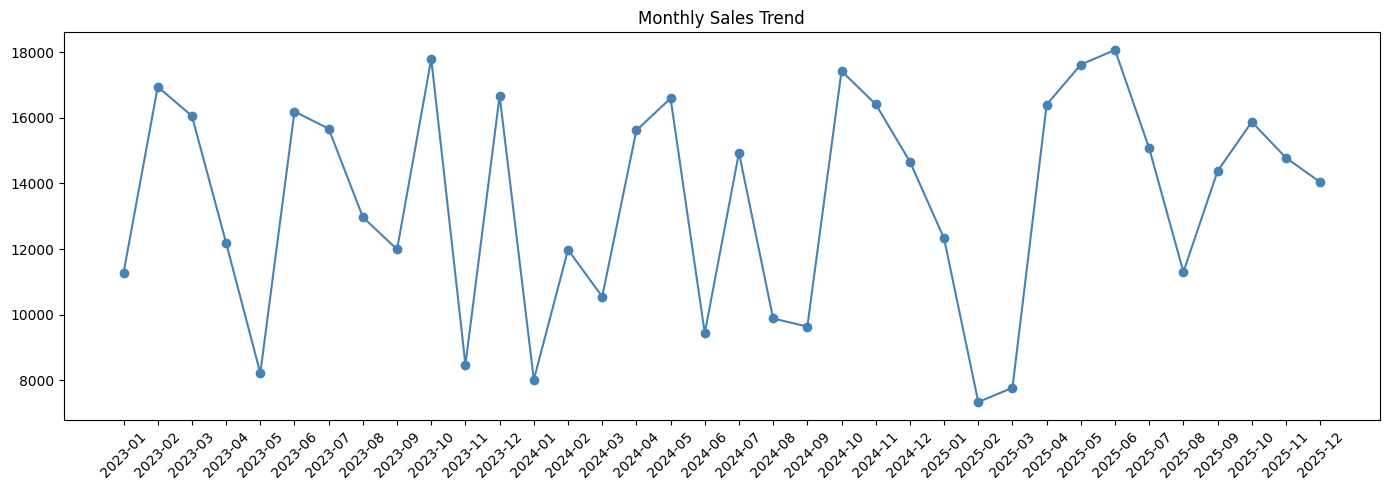

In [63]:
SalesAnalysis['Month'] = SalesAnalysis['Order_Date'].dt.to_period('M')
Monthly = SalesAnalysis.groupby('Month')['Total_Sales'].sum().reset_index()
Monthly['Month'] = Monthly['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(Monthly['Month'], Monthly['Total_Sales'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

# Yearly Analysis

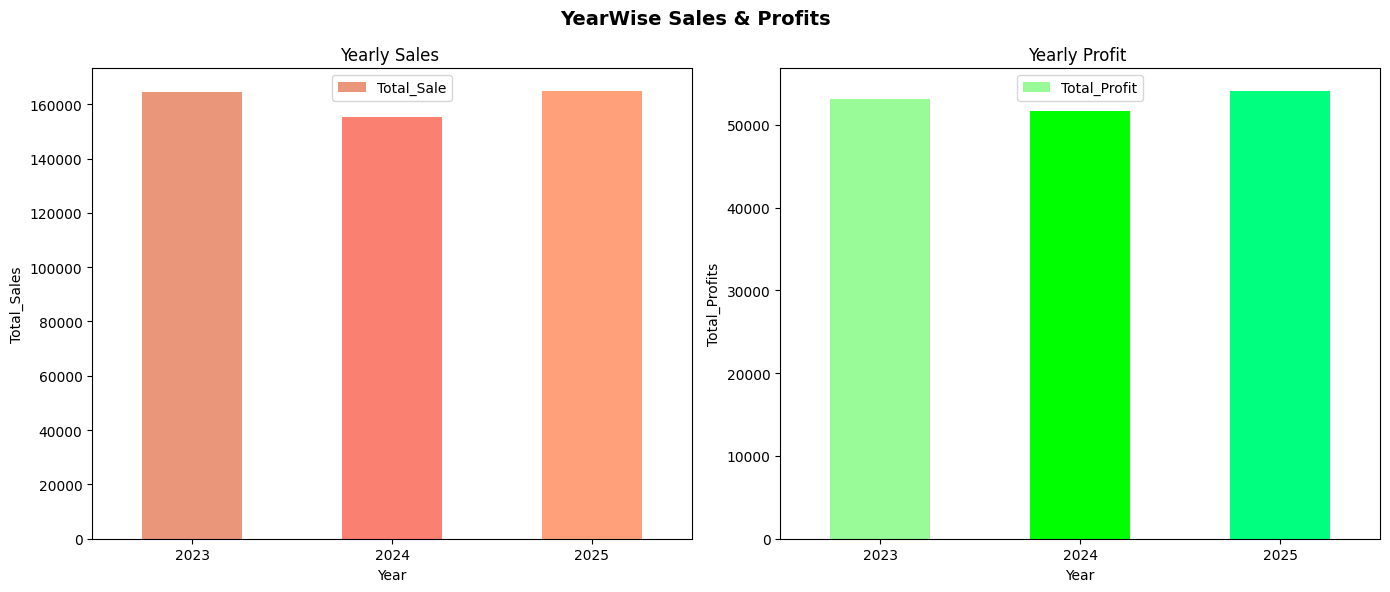

In [64]:
Yearly_Analysis = pd.read_sql("""
select strftime('%Y',Order_Date) As Year,
Sum(Total_Sales) As Total_Sale,
sum(Profit) As Total_Profit
from SalesAnalysis
group by Year
Order By Year
""",conn)
#Charts:
fig,ax=plt.subplots(1,2,figsize=(14,6))
plt.suptitle("YearWise Sales & Profits",fontsize=14,fontweight="bold" )
Yearly_Analysis.plot(kind='bar',x='Year',y='Total_Sale',color=['darksalmon','salmon','lightsalmon'],ax=ax[0])
ax[0].set_title('Yearly Sales ')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Total_Sales')
ax[0].tick_params(axis='x',rotation=0)
Yearly_Analysis.plot(kind='bar',x='Year',y='Total_Profit',color=['palegreen','lime','springgreen'],ax=ax[1])
ax[1].set_title('Yearly Profit ')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Total_Profits')
ax[1].tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show()


In [65]:
#.Sales Growth %:

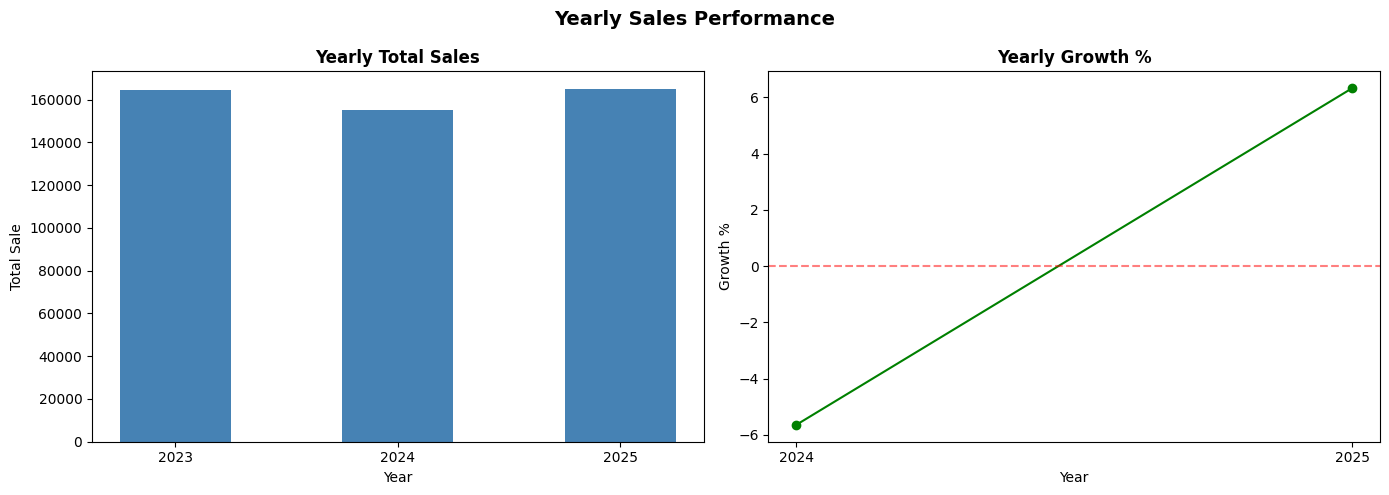

In [66]:
Yearly_Sales = pd.read_sql("""
    select strftime('%Y', Order_Date) As Year,
    Sum(Total_Sales) As Total_Sale
    from SalesAnalysis
    group by Year
    Order By Year
""", conn)

Yearly_Sales['Growth_%'] = Yearly_Sales['Total_Sale'].pct_change() * 100
Yearly_Sales['Growth_%'] = Yearly_Sales['Growth_%'].round(2)
#Charts:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - Total Sales
ax1.bar(Yearly_Sales['Year'], Yearly_Sales['Total_Sale'], color='steelblue', width=0.5)
ax1.set_title('Yearly Total Sales', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sale')

# Line chart - Growth %
ax2.plot(Yearly_Sales['Year'], Yearly_Sales['Growth_%'], color='Green', marker='o')
ax2.set_title('Yearly Growth %', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth %')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)  # zero reference line

plt.suptitle('Yearly Sales Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Discount:

In [68]:
#.Top Customer on Each Region:

In [69]:
Top_Customer = pd.read_sql("""
  select * from(
  select Customer_Name,Region,Product_Category,Product_Name,
  sum(Total_Sales) as Total_Sales,
  sum(Profit) As Total_Profit,
  Avg(Discount_Percent) as Avg_Discountpct,
  Row_number()over(partition by Region order by count(Quantity) desc)as High_Order
 from SalesAnalysis
 Group by Customer_Name,Region,Product_Category,Product_Name
 )
 where High_Order =1


""",conn)
Top_Customer.style \
    .set_caption("Top Customer Per Region") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}
    ]) \
    .hide(axis='index')

Customer_Name,Region,Product_Category,Product_Name,Total_Sales,Total_Profit,Avg_Discountpct,High_Order
Ahmed Anderson,Asia Pacific,Technology,Smart LED Desk Lamp,133.680000,46.970000,0.000000,1
Emma Müller,Europe,Clothing & Accessories,Travel Backpack 30L,455.730000,179.640000,12.500000,1
Sarah Davis,Middle East & Africa,Technology,Smart LED Desk Lamp,227.900000,63.790000,5.000000,1
Ingrid Clark,North America,Office Supplies,Ballpoint Pen Pack 12,38.130000,5.030000,10.000000,1
Raj Sato,South America,Office Supplies,Binder Clips Assorted 48pc,115.480000,19.830000,10.000000,1


In [70]:
#.Least buying Customer

In [143]:
Least_Buying = pd.read_sql("""
select * from(
select Customer_Name,Region,Product_Category,Product_Name,
Sum(Total_Sales) AS Total_Sales,
Sum(profit) As Total_Profits,
Avg(Discount_Percent) as Avg_Discountpct,
Row_Number()Over(partition by Region order by sum(Quantity)Desc) As Least_Buying
From SalesAnalysis
Group by Customer_Name,Region,Product_Category,Product_Name)
where Least_Buying = 190

""",conn)
Least_Buying
Least_Buying.style \
    .set_caption("Least Buying Customer Per Region") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}
    ]) \
    .hide(axis='index')

Customer_Name,Region,Product_Category,Product_Name,Total_Sales,Total_Profits,Avg_Discountpct,Least_Buying
Olga Russo,Asia Pacific,Furniture,Filing Cabinet 3-Drawer,842.600000,325.930000,0.000000,190
Olga Yamamoto,Europe,Technology,Portable External SSD 1TB,567.960000,240.470000,0.000000,190
Olga Robinson,Middle East & Africa,Furniture,Desk Organizer Set,38.350000,1.260000,5.000000,190
Olga Müller,North America,Technology,Wireless Bluetooth Headphones,802.070000,329.990000,5.000000,190
Zara Moreau,South America,Office Supplies,Desk Calendar 2025,6.830000,-8.710000,0.000000,190


# Payment:

     Payment_Method  Total_Order  Avg_Discountpct
0       Credit Card          797             8.72
1            PayPal          609             8.32
2  Cash on Delivery          301             8.85
3     Bank Transfer          293             8.41


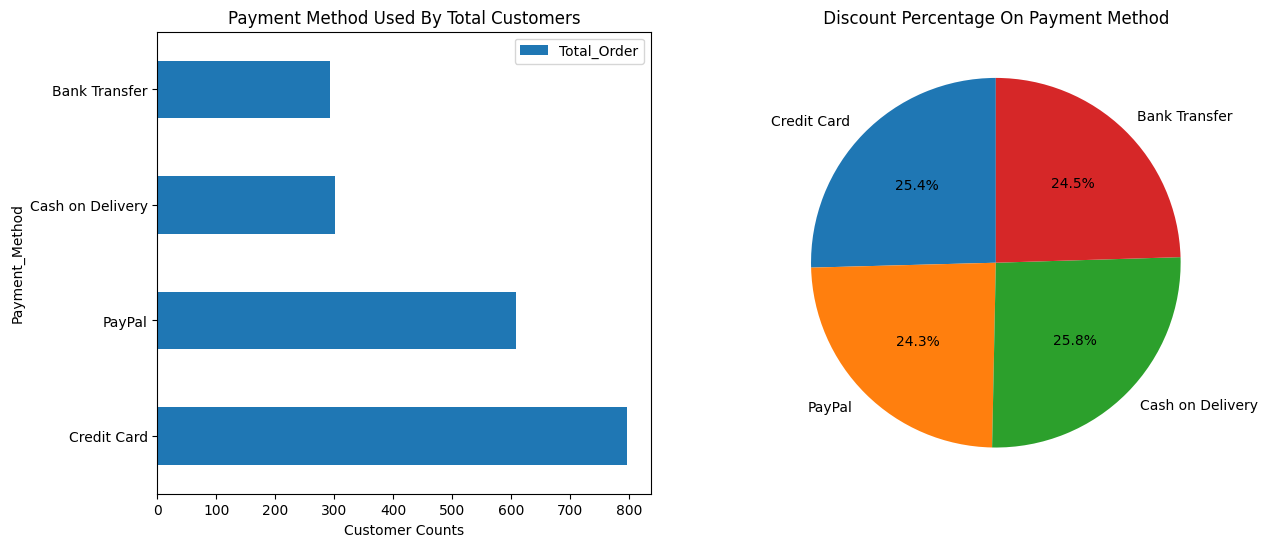

In [144]:

Discount = pd.read_sql("""
select Payment_Method,
Count(Order_ID) As Total_Order,
round(Avg(Discount_Percent),2) as Avg_Discountpct
from SalesAnalysis
Group by Payment_Method
order by Total_Order desc
""",conn)
print(Discount)

#.Charts:
fig,ax=plt.subplots(1,2,figsize=(14,6))
#Charts1:
Discount.plot(kind='barh',x='Payment_Method',y='Total_Order',ax=ax[0])
ax[0].set_title("Payment Method Used By Total Customers")
ax[0].set_xlabel("Customer Counts")
#.Charts2:
ax[1].pie(Discount['Avg_Discountpct'],labels=Discount['Payment_Method'],autopct='%1.1f%%',startangle=90)
ax[1].set_title(" Discount Percentage On Payment Method ")
plt.show()

# Top Country On Revenue:

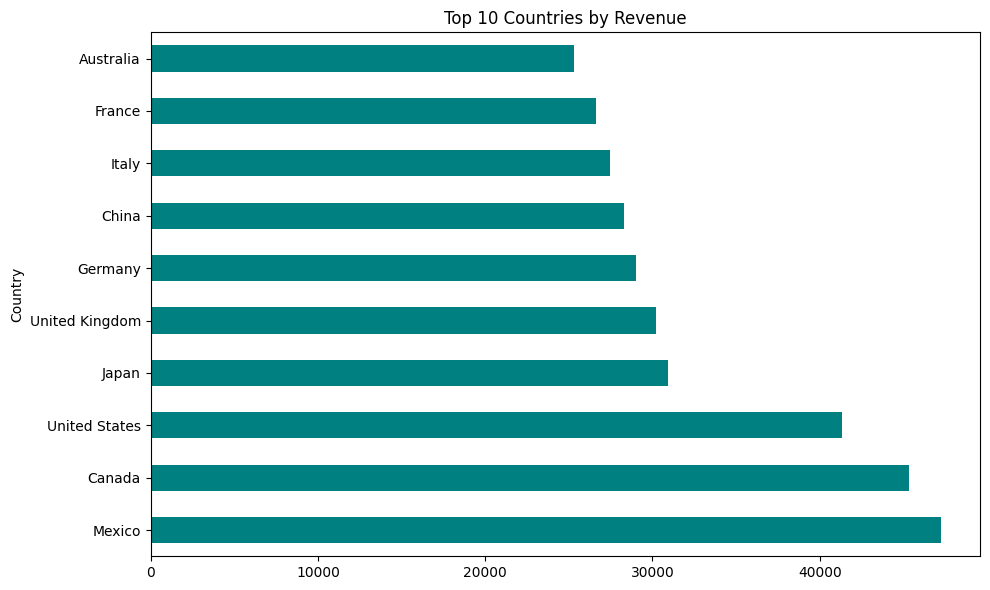

In [76]:
Country_Sales = pd.read_sql("""
    SELECT Country, ROUND(SUM(Total_Sales), 2) AS Revenue
    FROM SalesAnalysis
    GROUP BY Country
    ORDER BY Revenue DESC
    LIMIT 10
""", conn)

Country_Sales.plot(kind='barh', x='Country', y='Revenue', figsize=(10,6), color='teal', legend=False)
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.show()

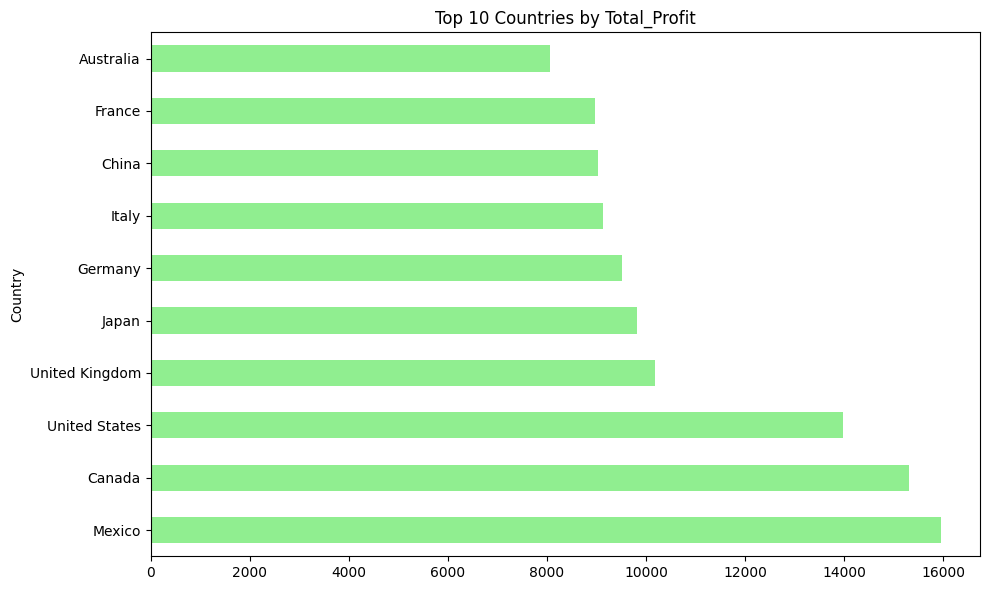

In [77]:
Country_Profit = pd.read_sql("""
    SELECT Country, ROUND(SUM(Profit), 2) AS Total_Profit
    FROM SalesAnalysis
    GROUP BY Country
    ORDER BY Total_Profit DESC
    LIMIT 10
""", conn)

Country_Profit.plot(kind='barh', x='Country', y='Total_Profit', figsize=(10,6), color='lightgreen', legend=False)
plt.title('Top 10 Countries by Total_Profit')
plt.tight_layout()
plt.show()

# Correlation Analysis

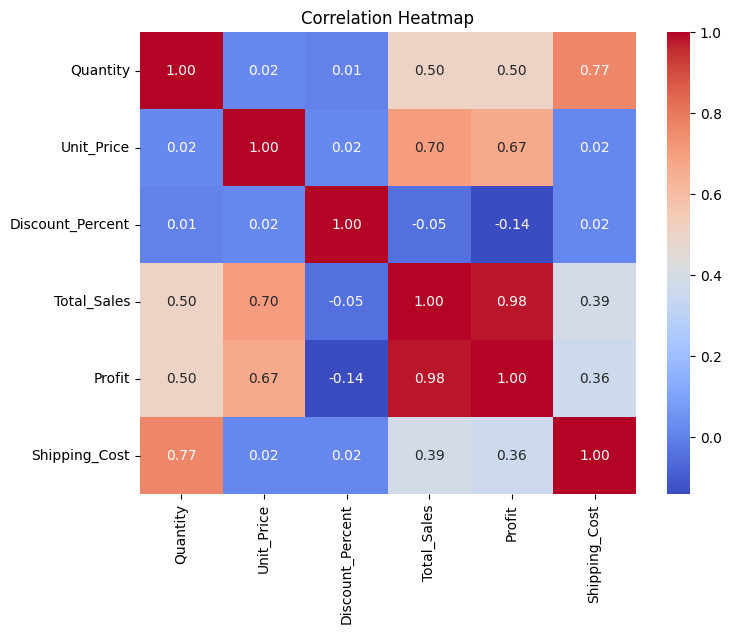

In [78]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    SalesAnalysis[['Quantity','Unit_Price','Discount_Percent','Total_Sales','Profit','Shipping_Cost']].corr(),
    annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

# Satistical Analysis:

In [79]:
Avg_Order=SalesAnalysis['Quantity'].mean()
Product_Sales = SalesAnalysis['Product_Name'].mode()[0]
High_Cost_Product = SalesAnalysis.groupby('Product_Name')['Unit_Price'].mean().idxmax()
Low_Cost_Product = SalesAnalysis.groupby('Product_Name')['Unit_Price'].mean().idxmin()
print(" Average Orders : ", Avg_Order)
print(" Repeatly Selling Product : ", Product_Sales)
print(" High_Cost_Product : ",High_Cost_Product)
print(" Low_Cost_Product : ",Low_Cost_Product)

 Average Orders :  3.5575
 Repeatly Selling Product :  Wireless Ergonomic Mouse
 High_Cost_Product :  Corner L-Shaped Desk
 Low_Cost_Product :  Paper Clips Box 500pc


In [118]:
#.Discont Vs Profit (T-Test)

In [104]:
from scipy.stats import ttest_ind
low_discount = SalesAnalysis[SalesAnalysis['Discount_Percent']< 10]['Profit']
High_discount = SalesAnalysis[SalesAnalysis['Discount_Percent'] >=10]['Profit']
t_stat, p_discount_profit = ttest_ind(low_discount,High_discount)
print("T-Statistic :",t_stat)
print("P-Value :",p_discount_profit )
if p_discount_profit   < 0.05:
  print("Discount Significantly Affects Profits")
else:
  print("No significant effect")

T-Statistic : 5.938590426461376
P-Value : 3.381967500727293e-09
Discount Significantly Affects Profits


Payment Method Vs Sales (ANOVA)

In [105]:
from scipy.stats import f_oneway

groups = [
    group['Total_Sales'].values
    for _, group in SalesAnalysis.groupby('Payment_Method')
]

f_stat, p_payment_Sales = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_payment_Sales)

if p_payment_Sales < 0.05:
    print("Sales differ by payment method")
else:
    print("No significant difference")


F-Statistic: 0.2103061212970062
P-Value: 0.889305785046146
No significant difference


In [119]:
#.Product Category vs Profit (ANOVA)

In [106]:
groups = [
    group['Profit'].values
    for _, group in SalesAnalysis.groupby('Product_Category')
]

f_stat, p_Category_Profit = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_Category_Profit)

if p_Category_Profit < 0.05:
    print("Profit differs across categories")
else:
    print("No significant difference")

F-Statistic: 129.32277028477364
P-Value: 1.4906784862212612e-76
Profit differs across categories


In [121]:
#.Discount vs Sales (Correlation)

In [107]:
from scipy.stats import pearsonr

corr, p_Discount_Sales = pearsonr(
    SalesAnalysis['Discount_Percent'],
    SalesAnalysis['Total_Sales']
)

print("Correlation:", corr)
print("P-Value:", p_Discount_Sales)

if p_Discount_Sales < 0.05:
    print("Significant relationship exists")
else:
    print("No significant relationship")

Correlation: -0.04589959165816937
P-Value: 0.040122009315039564
Significant relationship exists


In [108]:
results = {
    'Test': [
        'Discount vs Profit',
        'Payment Method vs Sales',
        'Category vs Profit',
        'Discount vs Sales'
    ],
    'P_Value': [
        p_discount_profit,
        p_payment_Sales,
        p_Category_Profit,
        p_Discount_Sales
    ]
}

summary = pd.DataFrame(results)
print(summary)

                      Test       P_Value
0       Discount vs Profit  3.381968e-09
1  Payment Method vs Sales  8.893058e-01
2       Category vs Profit  1.490678e-76
3        Discount vs Sales  4.012201e-02


In [94]:
# Predict Sales Using Discount:

Intercept: 271.42263536695475
Slope: -2.953713401264026


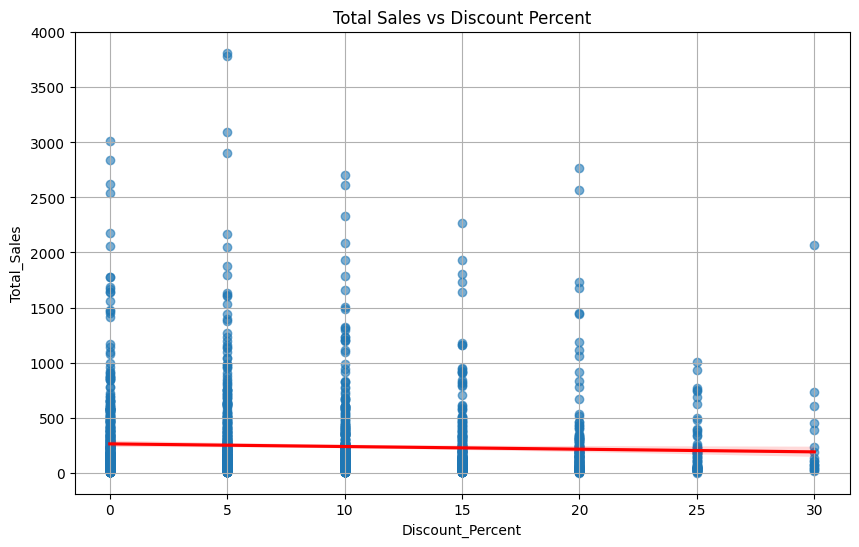

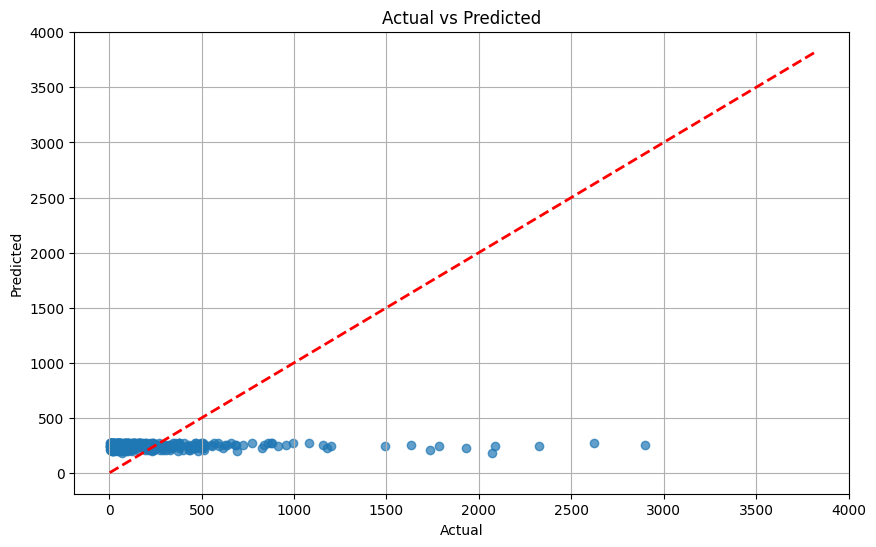

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = SalesAnalysis[['Discount_Percent']]
y = SalesAnalysis['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
#charts:
plt.figure(figsize=(10, 6))
sns.regplot(x='Discount_Percent', y='Total_Sales', data=SalesAnalysis,
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Total Sales vs Discount Percent')
plt.grid(True)
plt.show()

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()


In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features (X)
X = SalesAnalysis[['Total_Sales', 'Discount_Percent',
        'Product_Category', 'Payment_Method']]

# Target (Y)
y = SalesAnalysis['Profit']

# Convert categorical columns to numeric
X = pd.get_dummies(
    X,
    columns=['Product_Category', 'Payment_Method'],
    drop_first=True
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Intercept
print("\nIntercept:")
print(model.intercept_)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients:")
print(coef_df.sort_values('Coefficient', ascending=False))

R² Score: 0.9522372126646927
MAE: 12.409457956917468

Intercept:
17.032140784829522

Coefficients:
                            Feature  Coefficient
7             Payment_Method_PayPal     1.465531
5   Payment_Method_Cash on Delivery     1.432538
0                       Total_Sales     0.360440
6        Payment_Method_Credit Card    -1.044034
1                  Discount_Percent    -1.768211
4       Product_Category_Technology    -5.854604
3  Product_Category_Office Supplies    -9.309419
2        Product_Category_Furniture   -23.262874


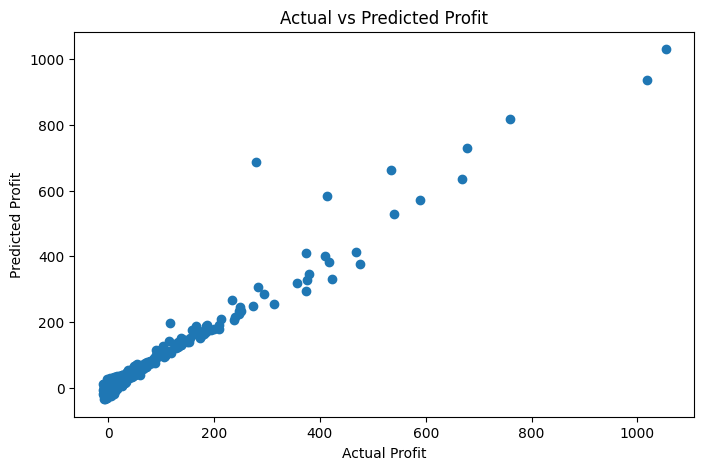

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

# 🧾 Overall Summary

## Key Performance Indicators
- **Total Revenue:** $484,559.34
- **Total Profit:** $158,872.32
- **Overall Profit Margin:** 32.79%
- **Total Orders:** 2,000
- **Average Order Value:** $242.28
- **Top Region by Sales:** Europe

## Product Category Insights
- **Furniture** is the top-performing category by both sales ($256,274.68) and profit ($81,171.57), with 10.98% YoY sales growth, but its profit margin (31.67%) is held back by a high average discount of 25.2%.
- **Technology** ($139,518.22 sales, $48,268.65 profit) has a strong 28.6% profit margin and is growing 6.59% YoY — a promising area for further investment.
- **Clothing** has the highest profit margin (31.1%) but sales declined -5.57% YoY.
- **Office Supplies** is the weakest category — lowest sales ($19,390.81), lowest profit margin (17.12%), a 2nd-highest discount rate (25.1%), and declining sales (-4.10% YoY).
- **Recommendation:** Reduce reliance on heavy discounting for Furniture and Office Supplies, and prioritize investment in Technology (and Clothing) where margins and/or growth are stronger.

## Regional Insights
- **Europe** leads in sales ($137,006.20) with the strongest YoY growth (+34.88%) and a healthy 20.6% margin.
- **North America** is close behind in sales ($133,876.38) with the highest profit margin (20.9%), but sales declined -8.68% YoY.
- **Middle East & Africa** and **South America** are the lowest-performing regions on both sales and profit. South America's sales declined sharply (-28.29% YoY) despite the highest discount rate (21.6%).
- **Recommendation:** Replicate Europe's growth drivers in North America to reverse its decline, and investigate why high discounts in South America are not converting into sales growth.

## Customer Segment Insights
- **Consumer** segment dominates sales ($256,287.74) and profit ($87,300.36) with the highest margin (34.9%) and the lowest average discount (7.20%) — despite a -9.75% YoY sales decline.
- **Home Office** segment has the lowest sales ($82,221.21) but the fastest growth (+58.78% YoY), suggesting strong future potential.
- **Recommendation:** The data suggests lower discounting correlates with higher margins (Consumer segment). Consider testing reduced discounting strategies for other segments while nurturing the high-growth Home Office segment.

## Statistical Findings
| Test | Result | P-Value | Conclusion |
|---|---|---|---|
| Discount vs Profit (T-Test) | T = 5.94 | 3.38e-09 | **Significant** — discount level meaningfully affects profit |
| Payment Method vs Sales (ANOVA) | F = 0.21 | 0.889 | Not significant — payment method does not affect sales |
| Product Category vs Profit (ANOVA) | F = 129.32 | 1.49e-76 | **Significant** — profit varies strongly by category |
| Discount vs Sales (Pearson) | r = -0.046 | 0.040 | **Significant**, but very weak negative correlation |

## Predictive Modeling
- A **Linear Regression model** predicting **Profit** from Total Sales, Discount %, Product Category, and Payment Method achieved an **R² of 0.952** (MAE ≈ 12.41), indicating the model explains ~95% of the variance in profit.
- **Product Category** has the strongest negative impact on profit relative to the baseline (notably Furniture: -23.26), reinforcing that category mix is the biggest lever for profitability.
- **Discount Percent** has a small negative coefficient (-1.77), confirming that higher discounts modestly erode profit.

## Final Recommendations
1. **Rebalance discounting** — high discounts on Furniture and Office Supplies are eroding margins without proportional sales gains.
2. **Double down on Technology and Clothing** — strong margins and/or growth make these categories attractive for further investment.
3. **Investigate North America's decline** and South America's discount-driven underperformance to identify corrective actions.
4. **Leverage the Home Office segment's high growth** while maintaining the low-discount strategy that makes the Consumer segment so profitable.
5. Payment method has **no significant effect** on sales — no need to incentivize a particular payment channel.

---
*Analysis performed using Python (Pandas, NumPy, Matplotlib, Seaborn, SQLite3, SciPy, Scikit-learn).*